# 04 (v2) — Hybrid lift from the v2 CSV

Mirrors `04_hybrid_lift.ipynb` but uses the v2 CSV (2026-05-20). Same recipe:

```
For d < CAMPAIGN_LAUNCH (2026-04-06):       lift(d) = 0
For CAMPAIGN_LAUNCH ≤ d ≤ training_end:     lift(d) = fenix_gap_daily(d)
For d > training_end:                       lift(d) = fenix_gap_daily(training_end)
                                                      + (csv_daily_paid(d) − csv_daily_paid(training_end))
```

The **historical portion is identical to v1's hybrid** (same gap = June actuals − April mktg-off forecast). Only the **future portion** differs, because the v2 CSV has a different forward trajectory (peak around 2026-06, then decline) than v1 (monotonic growth).

Expected year-end magnitude is materially lower than v1's hybrid (+797k MA28) because v2's forward CSV delta from training_end is smaller.

Comparison panel overlays the v2 hybrid against v1 hybrid (`data/marketing_lift_model.hybrid.2026-05-19.parquet`) and the empirical Fenix gap.


In [1]:
# [setup]
import hashlib
import json
import subprocess
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Paths
SOURCE_CSV = Path('data/paid_dau_weekly_forecast.v2_model.20260520.csv')
OUT_PARQUET = Path('data/marketing_lift_model.real_data_v2.hybrid.2026-05-20.parquet')
OUT_META = Path('data/marketing_lift_model.real_data_v2.hybrid.2026-05-20.meta.json')
V1_HYBRID_PARQUET = Path('data/marketing_lift_model.hybrid.2026-05-19.parquet')

APRIL_FORECAST_PATH = Path(
    '/Users/brendanwells/work/mozaic-daily/data-official/2026-04/'
    'mobile_cps0.02_thresh32_recent13_clip0.6/'
    'mozaic_daily_forecast.2026-04-01.gm-D.raw.parquet'
)
JUNE_FORECAST_PATH = Path(
    '/Users/brendanwells/work/mozaic-daily/data-official/2026-06/'
    'mobile_cps0.02_thresh32_recent13_clip0.6_cap426/'
    'mozaic_daily_forecast.2026-05-17.gm-D.raw.parquet'
)

# Dates
CAMPAIGN_LAUNCH = pd.Timestamp('2026-04-06')
PARQUET_START = pd.Timestamp('2026-02-01')
PARQUET_END = pd.Timestamp('2026-12-31')
BASELINE_START = pd.Timestamp('2026-02-01')
BASELINE_END = pd.Timestamp('2026-03-28')
LAST_HISTORICAL_DATE = pd.Timestamp('2026-05-20')  # v2 CSV generation date

MA_WINDOW = 28

EASTER_MASK_DATES = pd.DatetimeIndex(sorted(set(
    [pd.Timestamp('2026-04-05') + pd.Timedelta(days=d) for d in range(-2, 3)] +
    [pd.Timestamp('2026-04-18') + pd.Timedelta(days=d) for d in range(-2, 3)]
)))


def _load_forecast(path):
    df = pd.read_parquet(path)
    df['target_date'] = pd.to_datetime(df['target_date'])
    return df


def _aggregate(df, country, app_name, data_type_filter=None):
    rollup = df[(df['data_source'] == 'glean_mobile')
                & (df['country'] == country)
                & (df['app_name'] == app_name)
                & (df['segment'] == '{}')].copy()
    if data_type_filter is not None:
        rollup = rollup[rollup['data_type'] == data_type_filter]
    return rollup.set_index('target_date').sort_index()['dau']


In [2]:
# [load-csv-daily]
# Read v2 CSV directly. Same interpolation pattern as nb2 (v2): snapshot
# interpretation, linear interp between Monday anchors.

weekly_raw = pd.read_csv(SOURCE_CSV, thousands=',')
weekly_raw['week'] = pd.to_datetime(weekly_raw['week'])
weekly = (weekly_raw[['week', 'total_paid_dau']]
          .rename(columns={'week': 'week_starting'})
          .sort_values('week_starting')
          .reset_index(drop=True))
assert (weekly['week_starting'].dt.dayofweek == 0).all()

weekly_indexed = weekly.set_index('week_starting')['total_paid_dau'].astype('float64')
daily_index = pd.date_range(weekly_indexed.index.min(), PARQUET_END, freq='D')
csv_daily_paid = weekly_indexed.reindex(daily_index).interpolate(method='linear', limit_area='inside').ffill()
assert csv_daily_paid.isna().sum() == 0

print(f'v2 CSV daily paid DAU: {csv_daily_paid.index.min().date()} → {csv_daily_paid.index.max().date()}')
print(f'  Days: {len(csv_daily_paid)}')
print(f'  Value at LAST_HISTORICAL_DATE ({LAST_HISTORICAL_DATE.date()}): {csv_daily_paid.loc[LAST_HISTORICAL_DATE]:>10,.0f}')
print(f'  Value at year-end: {csv_daily_paid.loc[PARQUET_END]:>10,.0f}')


v2 CSV daily paid DAU: 2026-01-05 → 2026-12-31
  Days: 361
  Value at LAST_HISTORICAL_DATE (2026-05-20):  1,335,748
  Value at year-end:  1,374,596


In [3]:
# [load-empirical-gap]
# Empirical Fenix Android gap = (June actuals − April mktg-off forecast) at
# country='ALL', app_name='fenix_android'. Same as v1's hybrid by construction —
# same April and June forecasts.

april = _load_forecast(APRIL_FORECAST_PATH)
june = _load_forecast(JUNE_FORECAST_PATH)

april_fenix_all = _aggregate(april, country='ALL', app_name='fenix_android')
actuals_fenix_all = _aggregate(june, country='ALL', app_name='fenix_android', data_type_filter='training')

gap_overlap = april_fenix_all.index.intersection(actuals_fenix_all.index)
fenix_gap_daily = (actuals_fenix_all.reindex(gap_overlap)
                   - april_fenix_all.reindex(gap_overlap)).rename('fenix_gap_daily')

training_end_actual = actuals_fenix_all.dropna().index.max()
print(f'June Fenix actuals training_end: {training_end_actual.date()}')
print(f'Gap coverage: {fenix_gap_daily.index.min().date()} → {fenix_gap_daily.index.max().date()}')
print(f'Gap on CAMPAIGN_LAUNCH ({CAMPAIGN_LAUNCH.date()}):   {fenix_gap_daily.loc[CAMPAIGN_LAUNCH]:>+10,.0f}')
print(f'Gap on training_end ({training_end_actual.date()}):  {fenix_gap_daily.loc[training_end_actual]:>+10,.0f}')
print()
print('Daily gap stats (post-campaign):')
post = fenix_gap_daily.loc[CAMPAIGN_LAUNCH:training_end_actual]
print(f'  N days:   {len(post)}')
print(f'  Mean:     {post.mean():>+10,.0f}')
print(f'  Min:      {post.min():>+10,.0f}  at {post.idxmin().date()}')
print(f'  Max:      {post.max():>+10,.0f}  at {post.idxmax().date()}')


June Fenix actuals training_end: 2026-05-16
Gap coverage: 2021-01-01 → 2026-05-16
Gap on CAMPAIGN_LAUNCH (2026-04-06):       -3,985
Gap on training_end (2026-05-16):    +494,378

Daily gap stats (post-campaign):
  N days:   41
  Mean:       +332,450
  Min:          -3,985  at 2026-04-06
  Max:        +591,504  at 2026-05-14


In [4]:
# [build-hybrid]
# Construct the v2 hybrid daily lift series. Same recipe as v1 hybrid, just
# different forward CSV.

training_end = training_end_actual

gap_at_training_end = float(fenix_gap_daily.loc[training_end])
csv_at_training_end = float(csv_daily_paid.loc[training_end])

print(f'Stitch parameters:')
print(f'  training_end:                 {training_end.date()}')
print(f'  gap_at_training_end:          {gap_at_training_end:>+10,.0f}')
print(f'  v2_csv_paid_at_training_end:  {csv_at_training_end:>10,.0f}')
print(f'  v2_csv_paid_at_year_end:      {csv_daily_paid.loc[PARQUET_END]:>10,.0f}')
print(f'  forward CSV delta:            {csv_daily_paid.loc[PARQUET_END] - csv_at_training_end:>+10,.0f}')
print()

full_index = pd.date_range(PARQUET_START, PARQUET_END, freq='D')

# Future portion: anchored CSV growth
future_csv_delta = csv_daily_paid - csv_at_training_end
future_lift = future_csv_delta + gap_at_training_end

# Combine: historical = raw gap, future = anchored CSV
hybrid_lift = pd.Series(0.0, index=full_index, name='marketing_lift_daily')

hist_mask = (full_index >= CAMPAIGN_LAUNCH) & (full_index <= training_end)
hist_dates = full_index[hist_mask]
hybrid_lift.loc[hist_dates] = fenix_gap_daily.reindex(hist_dates).values

future_mask = full_index > training_end
future_dates = full_index[future_mask]
hybrid_lift.loc[future_dates] = future_lift.reindex(future_dates).values

assert hybrid_lift.isna().sum() == 0
assert (hybrid_lift.loc[:CAMPAIGN_LAUNCH - pd.Timedelta(days=1)] == 0.0).all()
assert hybrid_lift.loc[training_end] == gap_at_training_end
expected_next = gap_at_training_end + (csv_daily_paid.loc[training_end + pd.Timedelta(days=1)] - csv_at_training_end)
assert abs(hybrid_lift.loc[training_end + pd.Timedelta(days=1)] - expected_next) < 1e-6

print('v2 hybrid lift snapshot:')
print(f'  {"date":>10}  {"lift_daily":>14}  region')
snapshot_dates = [pd.Timestamp('2026-03-01'),
                  CAMPAIGN_LAUNCH,
                  pd.Timestamp('2026-05-01'),
                  training_end,
                  training_end + pd.Timedelta(days=1),
                  pd.Timestamp('2026-07-01'),
                  pd.Timestamp('2026-09-01'),
                  pd.Timestamp('2026-12-15'),
                  PARQUET_END]
for d in snapshot_dates:
    label = ''
    if d < CAMPAIGN_LAUNCH:
        label = 'pre-launch (0)'
    elif d <= training_end:
        label = 'historical (gap)'
    else:
        label = 'future (v2 csv-anchored)'
    val = hybrid_lift.loc[d]
    print(f'  {d.date()}  {val:>+14,.0f}  {label}')


Stitch parameters:
  training_end:                 2026-05-16
  gap_at_training_end:            +494,378
  v2_csv_paid_at_training_end:   1,315,453
  v2_csv_paid_at_year_end:       1,374,596
  forward CSV delta:               +59,143

v2 hybrid lift snapshot:
        date      lift_daily  region
  2026-03-01              +0  pre-launch (0)
  2026-04-06          -3,985  historical (gap)
  2026-05-01        +111,485  historical (gap)
  2026-05-16        +494,378  historical (gap)
  2026-05-17        +498,972  future (v2 csv-anchored)
  2026-07-01        +597,987  future (v2 csv-anchored)
  2026-09-01        +551,170  future (v2 csv-anchored)
  2026-12-15        +544,037  future (v2 csv-anchored)
  2026-12-31        +553,521  future (v2 csv-anchored)


In [5]:
# [compute-ma]
hybrid_lift_ma = (hybrid_lift
                  .rolling(window=MA_WINDOW, min_periods=14)
                  .mean()
                  .rename('marketing_lift_ma'))

fenix_gap_ma = fenix_gap_daily.rolling(MA_WINDOW, min_periods=14).mean().rename('fenix_gap_ma')

print('MA28 snapshot:')
print(f'  {"date":>10}  {"daily":>14}  {"ma28":>14}')
for d in [CAMPAIGN_LAUNCH, pd.Timestamp('2026-05-01'), training_end,
          pd.Timestamp('2026-07-01'), pd.Timestamp('2026-09-01'),
          pd.Timestamp('2026-12-15'), PARQUET_END]:
    daily_val = hybrid_lift.loc[d]
    ma_val = hybrid_lift_ma.loc[d]
    ma_str = f'{ma_val:>+14,.0f}' if pd.notna(ma_val) else f'{"NaN":>14}'
    print(f'  {d.date()}  {daily_val:>+14,.0f}  {ma_str}')


MA28 snapshot:
        date           daily            ma28
  2026-04-06          -3,985            -142
  2026-05-01        +111,485        +239,521
  2026-05-16        +494,378        +384,259
  2026-07-01        +597,987        +632,255
  2026-09-01        +551,170        +552,718
  2026-12-15        +544,037        +547,998
  2026-12-31        +553,521        +547,775


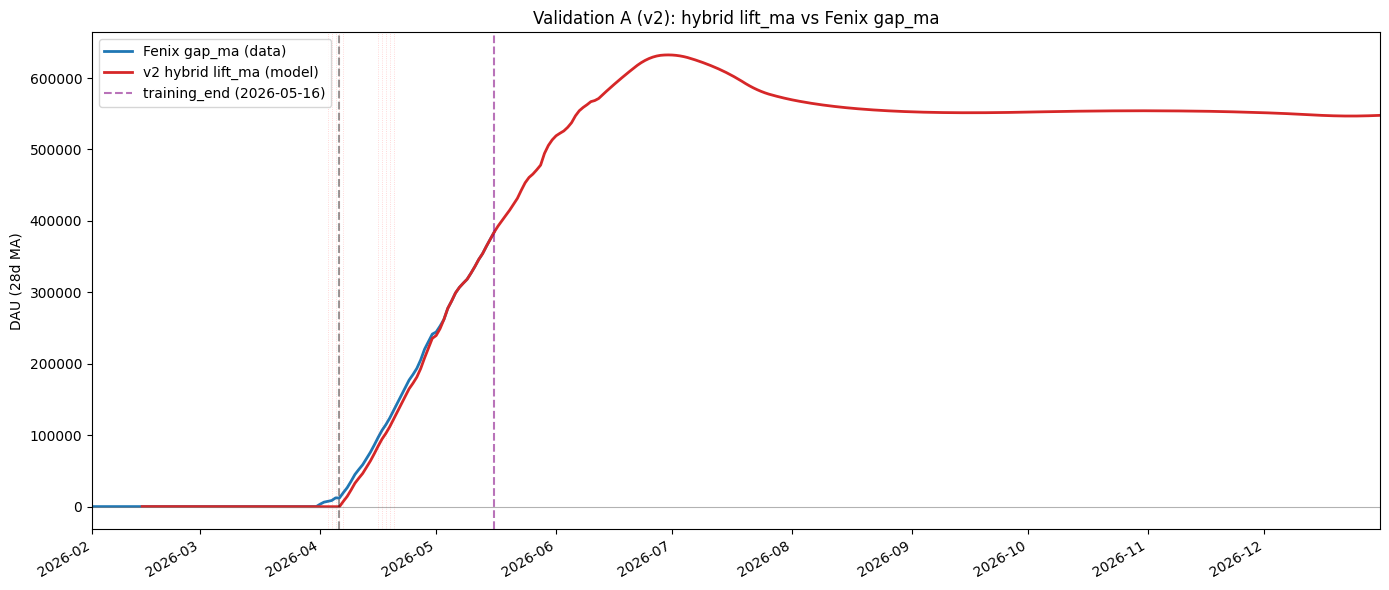

Validation A — residual (v2 hybrid_lift_ma − fenix_gap_ma):
  N days:   34
  Mean:         -6,427
  Std:          +5,843
  RMSE:         +8,629


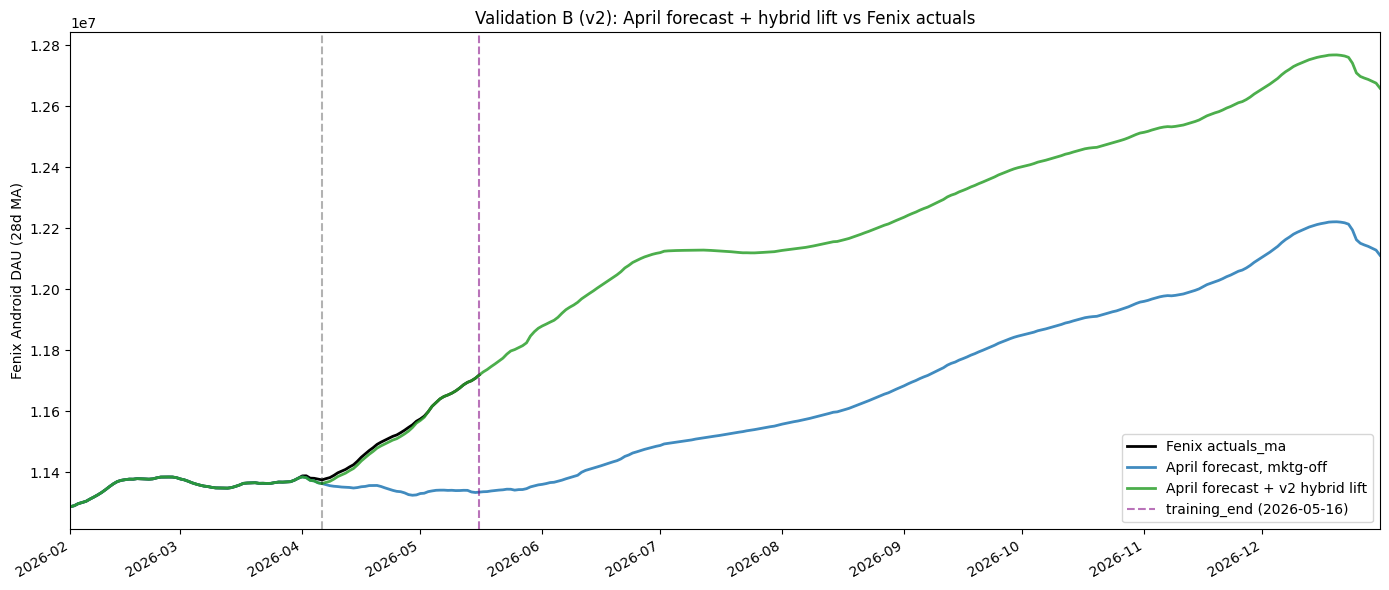

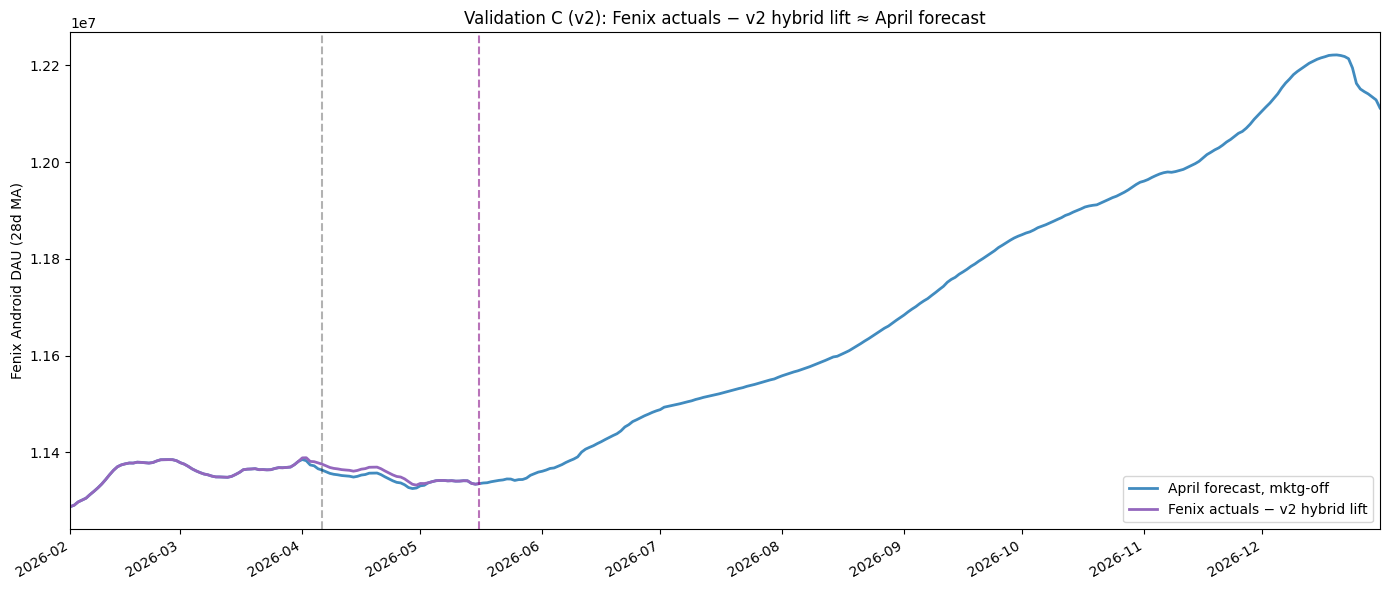

Validation C (v2) — counterfactual residual: (actuals − v2 hybrid lift) − April forecast
  N days:   105
  Mean:         +3,252
  Std:          +5,176
  Min:              -0  at 2026-05-03
  Max:         +12,197  at 2026-04-05


In [6]:
# [validation]
# Three views:
#   A — hybrid lift_ma vs Fenix gap_ma (post-campaign, MA)
#   B — april_ma + hybrid_lift_ma vs actuals_ma
#   C — actuals_ma − hybrid_lift_ma vs april_ma (counterfactual)

actuals_ma = actuals_fenix_all.rolling(MA_WINDOW, min_periods=14).mean().rename('actuals_ma')
april_ma = april_fenix_all.rolling(MA_WINDOW, min_periods=14).mean().rename('april_ma')

PLOT_START = pd.Timestamp('2026-02-01')
PLOT_END = pd.Timestamp('2026-12-31')
plot_index = pd.date_range(PLOT_START, PLOT_END, freq='D')

actuals_ma_v = actuals_ma.reindex(plot_index)
april_ma_v = april_ma.reindex(plot_index)
gap_ma_v = fenix_gap_ma.reindex(plot_index)
hybrid_ma_v = hybrid_lift_ma.reindex(plot_index)
combined_ma_v = april_ma_v + hybrid_ma_v.fillna(0.0)
actuals_minus_hybrid_v = actuals_ma_v - hybrid_ma_v.fillna(0.0)

# --- Validation A ---
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(gap_ma_v.index, gap_ma_v, '-', linewidth=2, color='C0',
        label='Fenix gap_ma (data)')
ax.plot(hybrid_ma_v.index, hybrid_ma_v, '-', linewidth=2, color='C3',
        label='v2 hybrid lift_ma (model)')
ax.axvline(CAMPAIGN_LAUNCH, color='black', linestyle='--', alpha=0.4)
ax.axvline(training_end, color='purple', linestyle='--', alpha=0.55,
           label=f'training_end ({training_end.date()})')
ax.axhline(0, color='grey', linewidth=0.8, alpha=0.6)
for d in EASTER_MASK_DATES:
    ax.axvline(d, color='red', linestyle=':', linewidth=0.6, alpha=0.2)
ax.set_title('Validation A (v2): hybrid lift_ma vs Fenix gap_ma')
ax.set_ylabel('DAU (28d MA)')
ax.set_xlim(PLOT_START, PLOT_END)
ax.legend(fontsize=10, loc='upper left')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

post_ix = pd.date_range(CAMPAIGN_LAUNCH, training_end, freq='D').difference(EASTER_MASK_DATES)
post_ix = post_ix.intersection(plot_index)
valid = hybrid_ma_v.reindex(post_ix).notna() & gap_ma_v.reindex(post_ix).notna()
post_ix = post_ix[valid]
a_resid = (hybrid_ma_v.reindex(post_ix) - gap_ma_v.reindex(post_ix))
a_resid_mean = float(a_resid.mean())
a_resid_std = float(a_resid.std())
a_resid_rmse = float(np.sqrt((a_resid ** 2).mean()))
print(f'Validation A — residual (v2 hybrid_lift_ma − fenix_gap_ma):')
print(f'  N days:   {len(a_resid)}')
print(f'  Mean:     {a_resid_mean:>+10,.0f}')
print(f'  Std:      {a_resid_std:>+10,.0f}')
print(f'  RMSE:     {a_resid_rmse:>+10,.0f}')

# --- Validation B ---
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(actuals_ma_v.index, actuals_ma_v, '-', linewidth=2, color='black',
        label='Fenix actuals_ma')
ax.plot(april_ma_v.index, april_ma_v, '-', linewidth=2, color='C0', alpha=0.85,
        label='April forecast, mktg-off')
ax.plot(combined_ma_v.index, combined_ma_v, '-', linewidth=2, color='C2', alpha=0.85,
        label='April forecast + v2 hybrid lift')
ax.axvline(CAMPAIGN_LAUNCH, color='black', linestyle='--', alpha=0.3)
ax.axvline(training_end, color='purple', linestyle='--', alpha=0.55,
           label=f'training_end ({training_end.date()})')
ax.set_xlim(PLOT_START, PLOT_END)
ax.set_title('Validation B (v2): April forecast + hybrid lift vs Fenix actuals')
ax.set_ylabel('Fenix Android DAU (28d MA)')
ax.legend(fontsize=10, loc='lower right')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# --- Validation C ---
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(april_ma_v.index, april_ma_v, '-', linewidth=2, color='C0', alpha=0.85,
        label='April forecast, mktg-off')
have_actuals = actuals_ma_v.notna()
ax.plot(actuals_minus_hybrid_v.index[have_actuals],
        actuals_minus_hybrid_v[have_actuals],
        '-', linewidth=2, color='C4',
        label='Fenix actuals − v2 hybrid lift')
ax.axvline(CAMPAIGN_LAUNCH, color='black', linestyle='--', alpha=0.3)
ax.axvline(training_end, color='purple', linestyle='--', alpha=0.55)
ax.set_xlim(PLOT_START, PLOT_END)
ax.set_title('Validation C (v2): Fenix actuals − v2 hybrid lift ≈ April forecast')
ax.set_ylabel('Fenix Android DAU (28d MA)')
ax.legend(fontsize=10, loc='lower right')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

c_resid = (actuals_minus_hybrid_v - april_ma_v).dropna()
c_resid_mean = float(c_resid.mean())
c_resid_std = float(c_resid.std())
c_resid_min = float(c_resid.min())
c_resid_max = float(c_resid.max())
print(f'Validation C (v2) — counterfactual residual: (actuals − v2 hybrid lift) − April forecast')
print(f'  N days:   {len(c_resid)}')
print(f'  Mean:     {c_resid_mean:>+10,.0f}')
print(f'  Std:      {c_resid_std:>+10,.0f}')
print(f'  Min:      {c_resid_min:>+10,.0f}  at {c_resid.idxmin().date()}')
print(f'  Max:      {c_resid_max:>+10,.0f}  at {c_resid.idxmax().date()}')


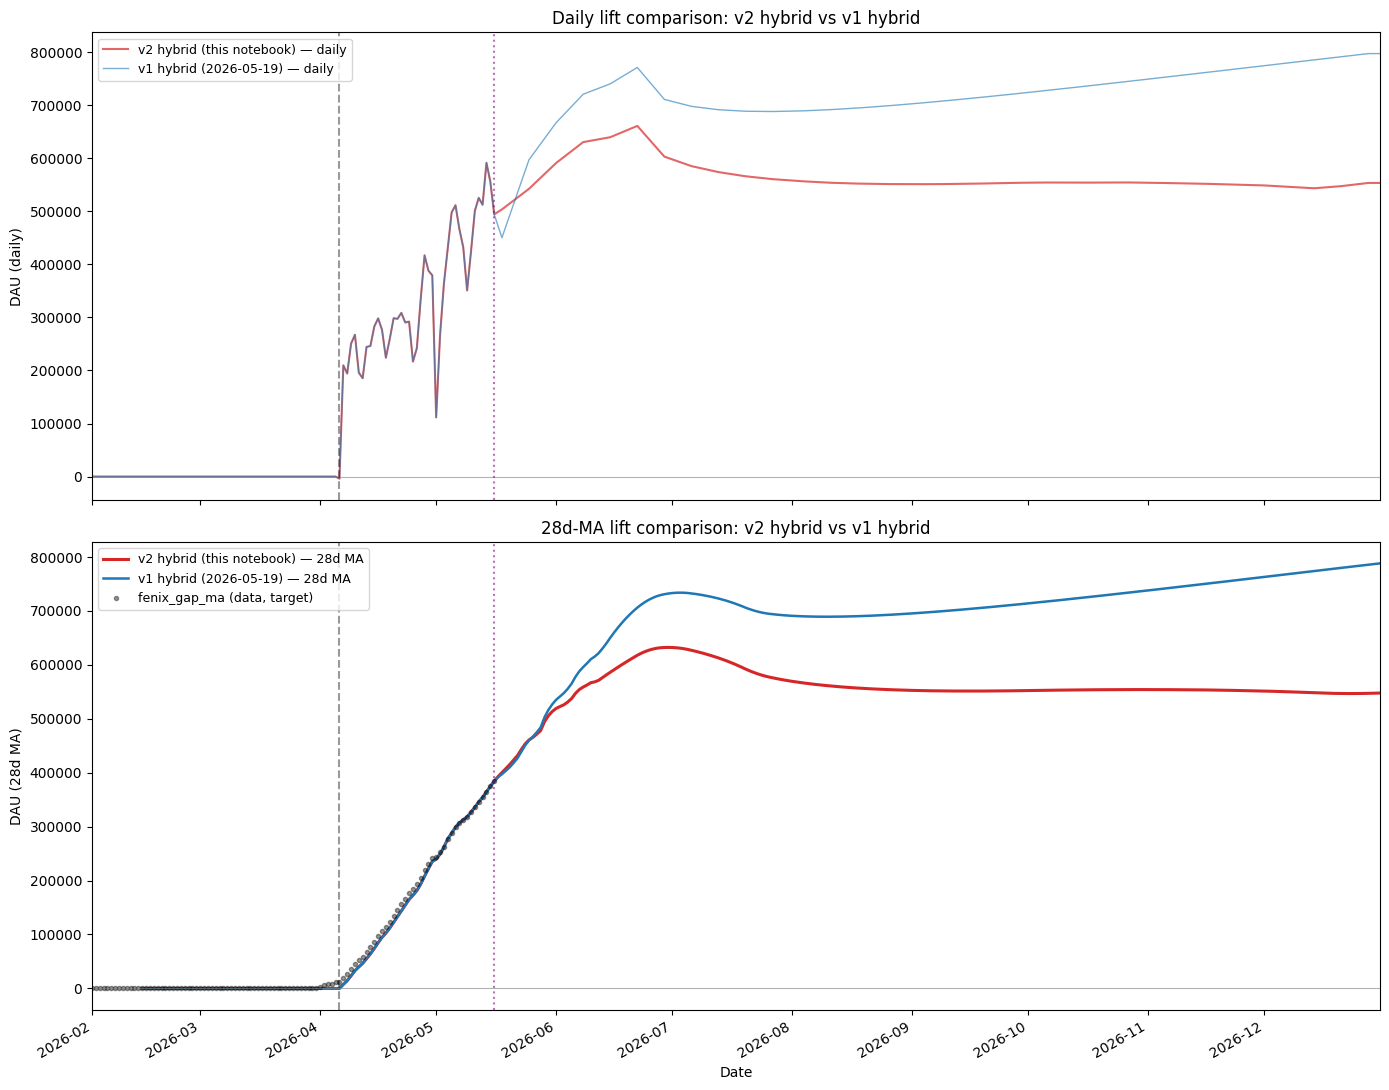

Year-end magnitudes:
  v2 hybrid daily lift @ 2026-12-31:      +553,521
  v2 hybrid 28d MA   @ 2026-12-31:        +547,775
  v1 hybrid daily lift @ 2026-12-31:      +797,352
  v1 hybrid 28d MA   @ 2026-12-31:        +788,275
  v2 − v1 (year-end MA delta):            -240,500


In [7]:
# [comparison-plot]
# Overlay v2 hybrid vs v1 hybrid (`marketing_lift_model.hybrid.2026-05-19.parquet`)
# vs empirical Fenix gap.

fig, (ax_daily, ax_ma) = plt.subplots(2, 1, figsize=(14, 11), sharex=True)

ax_daily.plot(hybrid_lift.index, hybrid_lift.values, '-', linewidth=1.5, color='C3', alpha=0.7,
              label='v2 hybrid (this notebook) — daily')
ax_ma.plot(hybrid_lift_ma.index, hybrid_lift_ma.values, '-', linewidth=2.2, color='C3',
           label='v2 hybrid (this notebook) — 28d MA')

# v1 hybrid (previous build)
try:
    v1_df = pd.read_parquet(V1_HYBRID_PARQUET)
    ax_daily.plot(v1_df.index, v1_df['marketing_lift_daily'], '-', linewidth=1.0, color='C0', alpha=0.6,
                  label='v1 hybrid (2026-05-19) — daily')
    ax_ma.plot(v1_df.index, v1_df['marketing_lift_ma'], '-', linewidth=1.8, color='C0',
               label='v1 hybrid (2026-05-19) — 28d MA')
except Exception as exc:
    print(f'WARN: could not load v1 hybrid parquet: {exc}')

ax_ma.plot(fenix_gap_ma.index, fenix_gap_ma.values, 'o', markersize=3, color='black', alpha=0.4,
           label='fenix_gap_ma (data, target)')

for ax in (ax_daily, ax_ma):
    ax.axhline(0, color='grey', linewidth=0.8, alpha=0.6)
    ax.axvline(CAMPAIGN_LAUNCH, color='black', linestyle='--', alpha=0.4)
    ax.axvline(training_end, color='purple', linestyle=':', alpha=0.55)
    ax.set_xlim(PLOT_START, PLOT_END)
    ax.legend(fontsize=9, loc='upper left')

ax_daily.set_title('Daily lift comparison: v2 hybrid vs v1 hybrid')
ax_daily.set_ylabel('DAU (daily)')
ax_ma.set_title('28d-MA lift comparison: v2 hybrid vs v1 hybrid')
ax_ma.set_ylabel('DAU (28d MA)')
ax_ma.set_xlabel('Date')
ax_ma.xaxis.set_major_locator(mdates.MonthLocator())
ax_ma.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print('Year-end magnitudes:')
print(f'  v2 hybrid daily lift @ 2026-12-31:    {hybrid_lift.loc[PARQUET_END]:>+10,.0f}')
print(f'  v2 hybrid 28d MA   @ 2026-12-31:      {hybrid_lift_ma.loc[PARQUET_END]:>+10,.0f}')
try:
    print(f'  v1 hybrid daily lift @ 2026-12-31:    {v1_df["marketing_lift_daily"].iloc[-1]:>+10,.0f}')
    print(f'  v1 hybrid 28d MA   @ 2026-12-31:      {v1_df["marketing_lift_ma"].iloc[-1]:>+10,.0f}')
    print(f'  v2 − v1 (year-end MA delta):          '
          f'{hybrid_lift_ma.loc[PARQUET_END] - v1_df["marketing_lift_ma"].iloc[-1]:>+10,.0f}')
except NameError:
    pass


In [8]:
# [build-and-write-artifact]
export_df = pd.DataFrame({
    'marketing_lift_daily': hybrid_lift.astype('float64'),
    'marketing_lift_ma': hybrid_lift_ma.astype('float64'),
})
export_df.index.name = 'target_date'
export_df.index = pd.DatetimeIndex(export_df.index).normalize()

# Compare schema against v1 hybrid (which was promoted) so we maintain the
# same parquet contract.
reference_df = pd.read_parquet(V1_HYBRID_PARQUET)
assert list(export_df.columns) == list(reference_df.columns)
assert export_df.dtypes.to_dict() == reference_df.dtypes.to_dict()
assert export_df.index.name == reference_df.index.name == 'target_date'
assert export_df.index.dtype == reference_df.index.dtype
assert export_df.index.is_unique
assert export_df.index.is_monotonic_increasing
assert export_df.index.min() == PARQUET_START
assert export_df.index.max() == PARQUET_END

OUT_PARQUET.parent.mkdir(exist_ok=True)
export_df.to_parquet(OUT_PARQUET)

artifact_sha1 = hashlib.sha1(OUT_PARQUET.read_bytes()).hexdigest()
source_csv_sha1 = hashlib.sha1(SOURCE_CSV.read_bytes()).hexdigest()

print(f'Wrote {OUT_PARQUET}')
print(f'  size: {OUT_PARQUET.stat().st_size:,} bytes')
print(f'  sha1: {artifact_sha1}')

git_hash = subprocess.check_output(
    ['git', 'rev-parse', 'HEAD'],
    cwd='/Users/brendanwells/work/mozaic-daily',
).decode().strip()

meta = {
    "model_name": "fenix_marketing_lift_hybrid_v2",
    "description": (
        "v2 hybrid marketing-lift series. Historical period (2026-04-06 → training_end): "
        "lift = empirical Fenix Android gap (June actuals − April mktg-off forecast). "
        "Future period (training_end+1 → 2026-12-31): lift anchored at empirical level on "
        "training_end, growing per the v2 marketing-team CSV's pattern from there. "
        "v2 CSV uses gt_1yr / lte_12mo cohort decomposition (vs v1's baseline_dau / post_2026_dau)."
    ),
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "mozaic_daily_git_hash": git_hash,
    "coverage": {
        "start_date": str(PARQUET_START.date()),
        "end_date": str(PARQUET_END.date()),
        "campaign_launch": str(CAMPAIGN_LAUNCH.date()),
        "training_end": str(training_end.date()),
        "forecast_end": str(PARQUET_END.date()),
    },
    "methodology": {
        "framing": "hybrid: empirical-actuals for historical period, CSV-anchored projection for future",
        "historical_rule": "lift(d) = fenix_gap_daily(d) for d in [CAMPAIGN_LAUNCH, training_end]; 0 pre-campaign",
        "future_rule": "lift(d) = gap_at_training_end + (csv_daily_paid(d) − csv_daily_paid(training_end)) for d > training_end",
        "gap_scope": "country='ALL', app_name='fenix_android'",
        "csv_version": "v2 (2026-05-20) — cohort-based decomposition",
    },
    "source_data": {
        "source_csv": str(SOURCE_CSV),
        "source_csv_sha1": source_csv_sha1,
        "april_forecast": str(APRIL_FORECAST_PATH),
        "june_forecast": str(JUNE_FORECAST_PATH),
        "v1_hybrid_predecessor": str(V1_HYBRID_PARQUET),
    },
    "validation": {
        "a_n_compare_days": int(len(a_resid)),
        "a_residual_mean": a_resid_mean,
        "a_residual_std": a_resid_std,
        "a_residual_rmse": a_resid_rmse,
        "c_n_counterfactual_days": int(len(c_resid)),
        "c_residual_mean": c_resid_mean,
        "c_residual_std": c_resid_std,
        "c_residual_min": c_resid_min,
        "c_residual_max": c_resid_max,
    },
    "caveats": [
        "Historical lift = raw daily fenix_gap_daily — carries DOW noise and non-marketing April-forecast errors.",
        "Future lift uses v2 CSV. v2 has a peak-then-decline shape (peak ~early-July), so the year-end magnitude is materially lower than v1's hybrid.",
        "Pre-campaign (< 2026-04-06) = 0 by convention.",
    ],
    "source_notebooks": [
        "02_v2_forecast_projection.ipynb",
        "03_v2_exploration.ipynb",
        "04_v2_hybrid_lift.ipynb",
    ],
    "artifact_sha1": artifact_sha1
}

with open(OUT_META, 'w') as f:
    json.dump(meta, f, indent=2)
print(f'Wrote {OUT_META}')


Wrote data/marketing_lift_model.real_data_v2.hybrid.2026-05-20.parquet
  size: 9,863 bytes
  sha1: bfc558b9855cf911182c277743fcde1e1577978b
Wrote data/marketing_lift_model.real_data_v2.hybrid.2026-05-20.meta.json


In [9]:
# [validate-via-loader]
loaded = pd.read_parquet(OUT_PARQUET)
series = loaded['marketing_lift_daily'].copy()
series.index = pd.DatetimeIndex(series.index).normalize()

assert series.index.is_unique
assert series.index.is_monotonic_increasing
assert not series.isna().any()
assert (series.loc[:CAMPAIGN_LAUNCH - pd.Timedelta(days=1)] == 0.0).all()

print('Loader-contract check: PASS')
print(f'  - index unique:      {series.index.is_unique}')
print(f'  - index sorted:      {series.index.is_monotonic_increasing}')
print(f'  - no NaN:            {not series.isna().any()}')
print(f'  - midnight index:    {(series.index == series.index.normalize()).all()}')
print(f'  - pre-launch zero:   {(series.loc[:CAMPAIGN_LAUNCH - pd.Timedelta(days=1)] == 0.0).all()}')
print(f'  - launch-day lift:   {series.loc[CAMPAIGN_LAUNCH]:>+10,.0f}')
print(f'  - training_end lift: {series.loc[training_end]:>+10,.0f}')
print(f'  - year-end lift:     {series.loc[PARQUET_END]:>+10,.0f}')
print()
print(f'Artifact: {OUT_PARQUET}')
print(f'Sidecar:  {OUT_META}')


Loader-contract check: PASS
  - index unique:      True
  - index sorted:      True
  - no NaN:            True
  - midnight index:    True
  - pre-launch zero:   True
  - launch-day lift:       -3,985
  - training_end lift:   +494,378
  - year-end lift:       +553,521

Artifact: data/marketing_lift_model.real_data_v2.hybrid.2026-05-20.parquet
Sidecar:  data/marketing_lift_model.real_data_v2.hybrid.2026-05-20.meta.json
